# A Data-Driven Exploration of Vehicle Performance and Trends

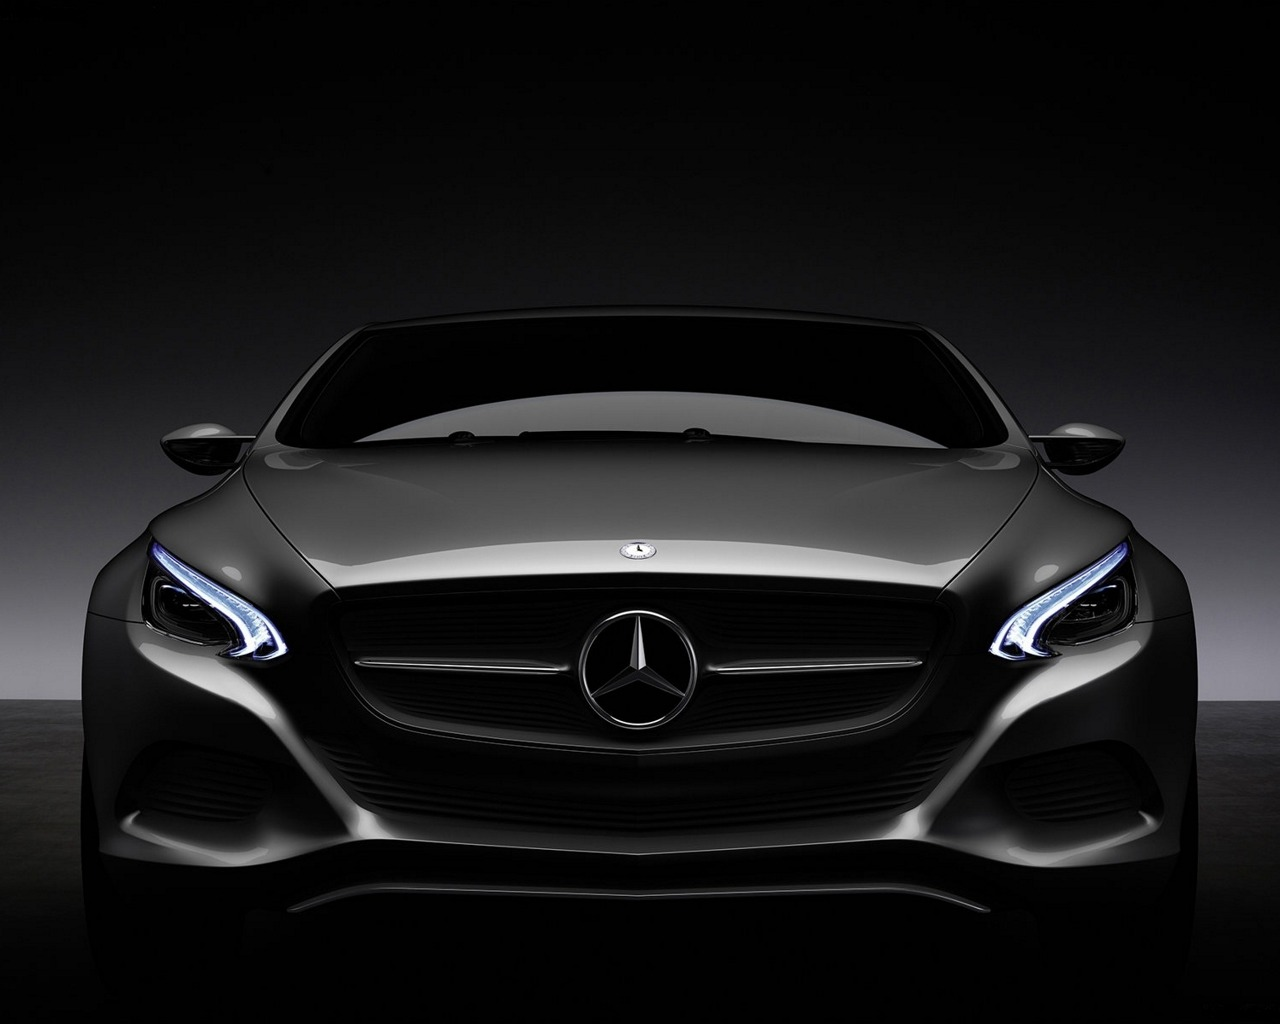

In [7]:
import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("cars.csv")

In [17]:
df.head()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
0,Chevrolet Chevelle Malibu,18.0,8,307.0,130,3504,12.0,70,US,US 70
1,Buick Skylark 320,15.0,8,350.0,165,3693,11.5,70,US,US 70
2,Plymouth Satellite,18.0,8,318.0,150,3436,11.0,70,US,US 70
3,AMC Rebel SST,16.0,8,304.0,150,3433,12.0,70,US,US 70
4,Ford Torino,17.0,8,302.0,140,3449,10.5,70,US,US 70


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car           406 non-null    object 
 1   MPG           406 non-null    float64
 2   Cylinders     406 non-null    int64  
 3   Displacement  406 non-null    float64
 4   Horsepower    406 non-null    int64  
 5   Weight        406 non-null    int64  
 6   Acceleration  406 non-null    float64
 7   Model         406 non-null    int64  
 8   Origin        406 non-null    object 
 9   Origin Model  406 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 31.8+ KB


In [21]:
print(df.isnull().sum())

Car             0
MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model           0
Origin          0
Origin Model    0
dtype: int64


In [23]:
print(df.duplicated().sum())

0


In [53]:
df=df[(df['MPG']>=30) & (df['Horsepower']>0)]
df

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,Origin Model
58,Peugeot 304,30.0,4,79.0,70,2074,19.5,71,Europe,Europe 71
59,Fiat 124B,30.0,4,88.0,76,2065,14.5,71,Europe,Europe 71
60,Toyota Corolla 1200,31.0,4,71.0,65,1773,19.0,71,Japan,Japan 71
61,Datsun 1200,35.0,4,72.0,69,1613,18.0,71,Japan,Japan 71
136,Datsun B210,31.0,4,79.0,67,1950,19.0,74,Japan,Japan 74
...,...,...,...,...,...,...,...,...,...,...
398,Toyota Celica GT,32.0,4,144.0,96,2665,13.9,82,Japan,Japan 82
399,Dodge Charger 2.2,36.0,4,135.0,84,2370,13.0,82,US,US 82
402,Volkswagen Pickup,44.0,4,97.0,52,2130,24.6,82,Europe,Europe 82
403,Dodge Rampage,32.0,4,135.0,84,2295,11.6,82,US,US 82


## "What are the key factors that influence a car's fuel efficiency (MPG)?"



In [56]:
# Calculate correlation of MPG with other numeric features
correlation = df.corr(numeric_only=True)['MPG'].sort_values(ascending=False)
correlation

MPG             1.000000
Model           0.325190
Acceleration    0.249768
Cylinders      -0.021682
Displacement   -0.096948
Weight         -0.162997
Horsepower     -0.308806
Name: MPG, dtype: float64

C:\Users\mahmo\AppData\Local\Temp\ipykernel_51460\2444500179.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values[1:], y=correlation.index[1:], palette='coolwarm')


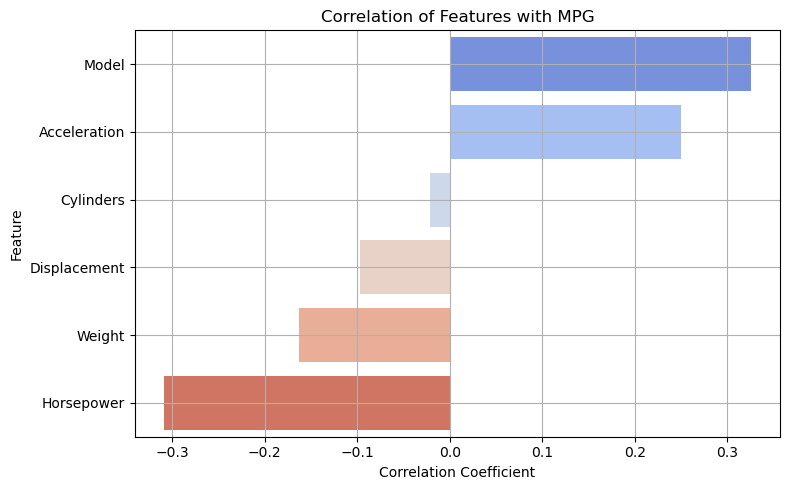

In [58]:
# Plot correlation of other features with MPG
plt.figure(figsize=(8, 5))
sns.barplot(x=correlation.values[1:], y=correlation.index[1:], palette='coolwarm')
plt.title('Correlation of Features with MPG')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

### The most important factors are Weight, Displacement, Cylinders, and Horsepower — all negatively affect MPG. Meanwhile, newer model years and better acceleration are associated with improved fuel efficiency.



## "what is the frequent of hoursepower of the cars?"

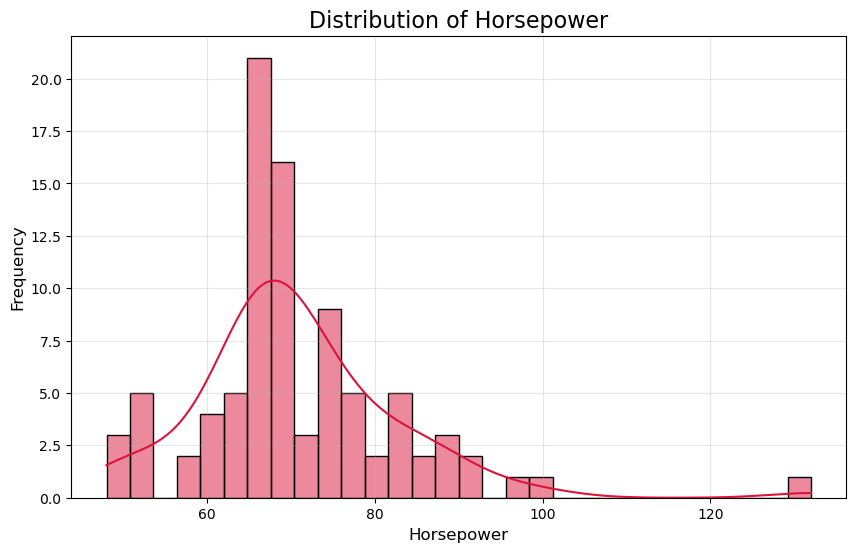

In [61]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Horsepower'], bins=30, kde=True, color='crimson')
plt.title('Distribution of Horsepower', fontsize=16)
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()
 

### Horsepower values are right-skewed, meaning most cars have lower to moderate horsepower, with fewer cars having high horsepower.

### The peak (mode) appears around 90–100 HP, indicating this is the most common horsepower range in the dataset.

### The distribution tapers off after 150 HP, with some outliers above 200 HP.

### The KDE curve confirms the skewness and highlights the concentration of cars with lower horsepower

## "what is the weight distribution?'
 

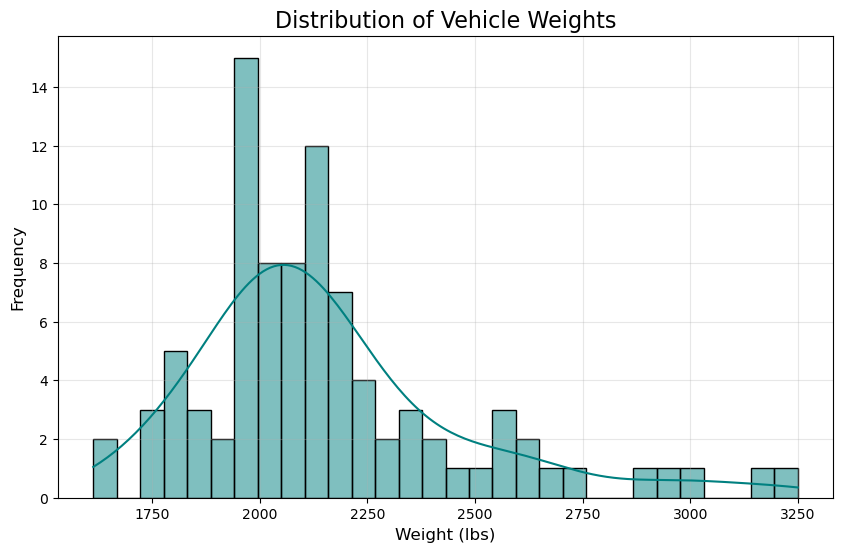

In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Weight'], bins=30, kde=True, color='teal')
plt.title('Distribution of Vehicle Weights', fontsize=16)
plt.xlabel('Weight (lbs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()
 

### The distribution is slightly right-skewed, meaning most vehicles in the dataset fall within the mid-range weight classes, with fewer heavier vehicles.

### The majority of cars have weights between approximately 2,500 and 4,000 lbs, suggesting this was the common weight range during that era.

### There is a smooth tapering beyond 4,000 lbs, indicating fewer very heavy vehicles.

### The KDE curve highlights a prominent peak around 3,000–3,500 lbs, which represents the most common vehicle weight range.

## "Are there MPG or performance differences across Origin (US, Europe, Japan)?"

In [72]:
# Group by Origin and calculate mean values for performance-related metrics

regional_insights = df.groupby('Origin')[['MPG', 'Horsepower', 'Weight', 'Acceleration']].mean().round(1)
regional_insights

 

,MPG,Horsepower,Weight,Acceleration
Origin,,,,
Europe,35.5,67.8,2254.8,17.7
Japan,34.6,69.7,2073.8,16.9
US,33.7,75.3,2241.2,15.3


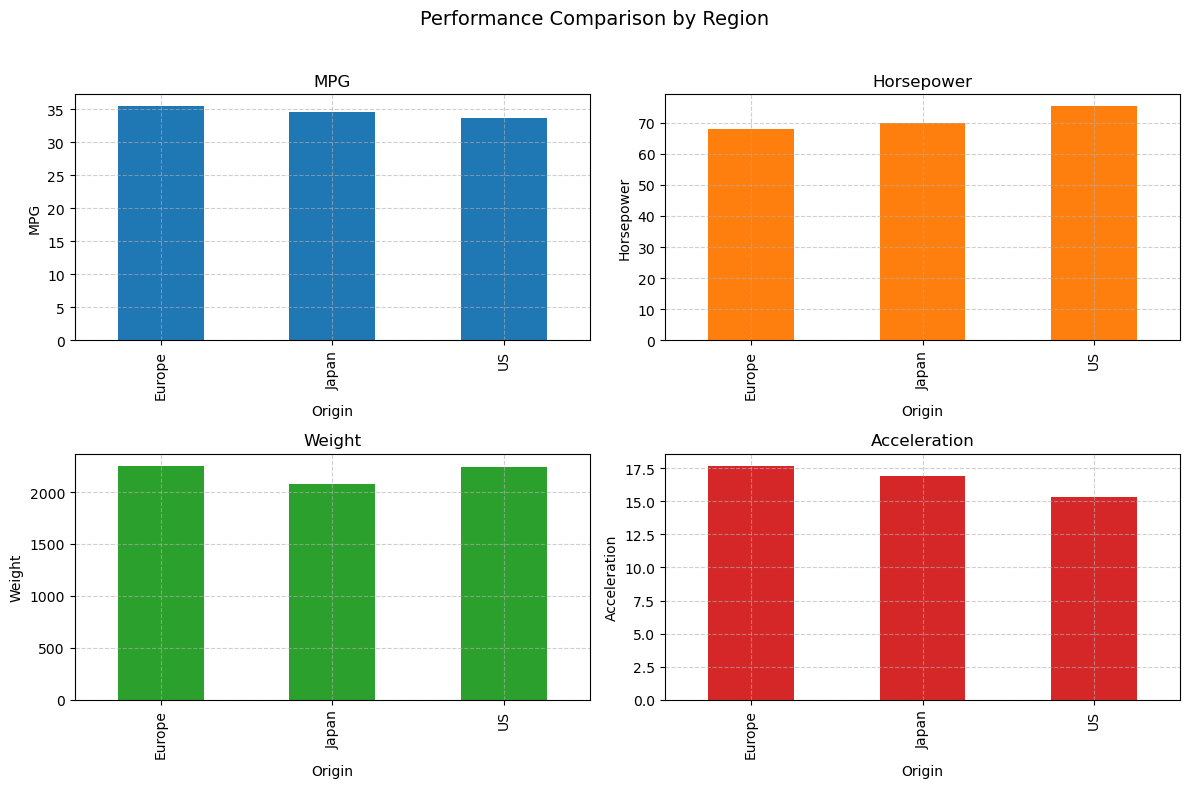

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Performance Comparison by Region', fontsize=14)
 
# Bar plots for each metric
metrics = ['MPG', 'Horsepower', 'Weight', 'Acceleration']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
 
for ax, metric, color in zip(axes.flatten(), metrics, colors):
    regional_insights[metric].plot(kind='bar', ax=ax, color=color)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('Origin')
    ax.grid(True, linestyle='--', alpha=0.6)
 
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
 

### Japanese cars: Lightest, most fuel-efficient, modest horsepower, slower acceleration.
### European cars: In the middle for everything—balanced MPG, weight, and performance.
### US cars: Heaviest, lowest MPG, highest horsepower, fastest acceleration.
 

## "what is top 10 fastest cars?"

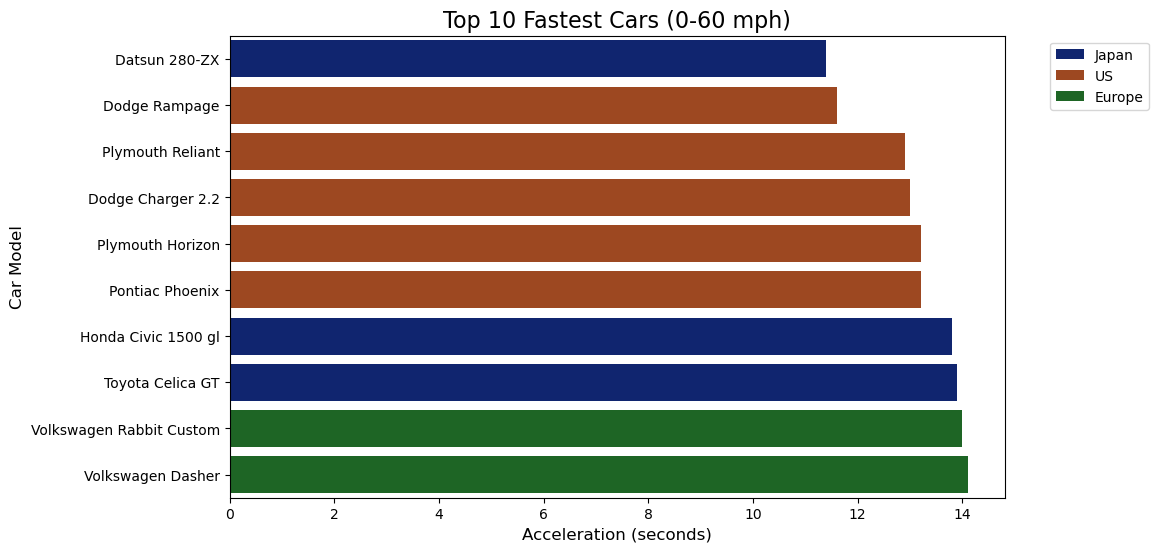

In [81]:
# Fastest cars (lowest acceleration time)
fastest = df.nsmallest(10, 'Acceleration')[['Car', 'Acceleration', 'Origin']]
fastest.sort_values('Acceleration', inplace=True)
 
plt.figure(figsize=(10, 6))
sns.barplot(data=fastest, x='Acceleration', y='Car', hue='Origin', dodge=False, palette='dark')
plt.title('Top 10 Fastest Cars (0-60 mph)', fontsize=16)
plt.xlabel('Acceleration (seconds)', fontsize=12)
plt.ylabel('Car Model', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Summary of Insights:
## 1- Vehicle Weight Distribution:

### The distribution is slightly right-skewed, meaning most vehicles fall in the mid-weight range.

### Most cars weigh between 2,500–4,000 lbs, with a peak around 3,000–3,500 lbs.

### Fewer vehicles are above 4,000 lbs.


## 2- Country-Based Vehicle Comparison:

### Japanese cars: Lightest, most fuel-efficient, lower horsepower, and slower acceleration.

### European cars: Balanced in terms of MPG, weight, and performance.

### US cars: Heaviest, lowest fuel efficiency, highest horsepower, and fastest acceleration.

